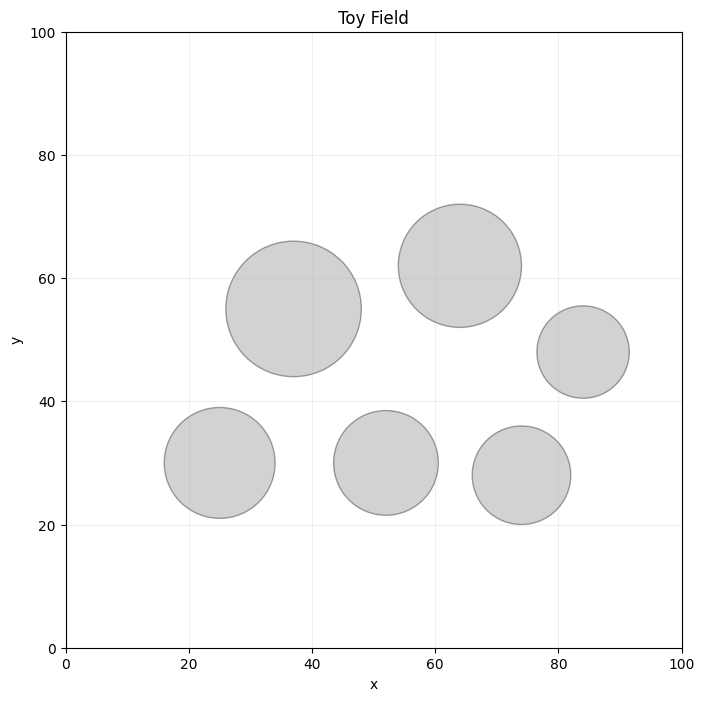

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Toy Field'}, xlabel='x', ylabel='y'>)

In [ ]:
from Agent import Agent
from FieldClass import ToyFieldClass
from RRT import RRTParameters
from utils.visualization import plot_agent

bounds = (0.0, 100.0, 0.0, 100.0)
start = (8.0, 8.0)
goal = (92.0, 90.0)

# Fixed circular obstacles for a deterministic toy benchmark.
obstacles = [
    (25.0, 30.0, 9.0),
    (37.0, 55.0, 11.0),
    (52.0, 30.0, 8.5),
    (64.0, 62.0, 10.0),
    (74.0, 28.0, 8.0),
    (84.0, 48.0, 7.5),
]

field = ToyFieldClass(bounds=bounds, obstacles=obstacles, robot_radius=0.6)
field.plot(title="Toy Field")

Path found with 51 waypoints
Path length: 158.60


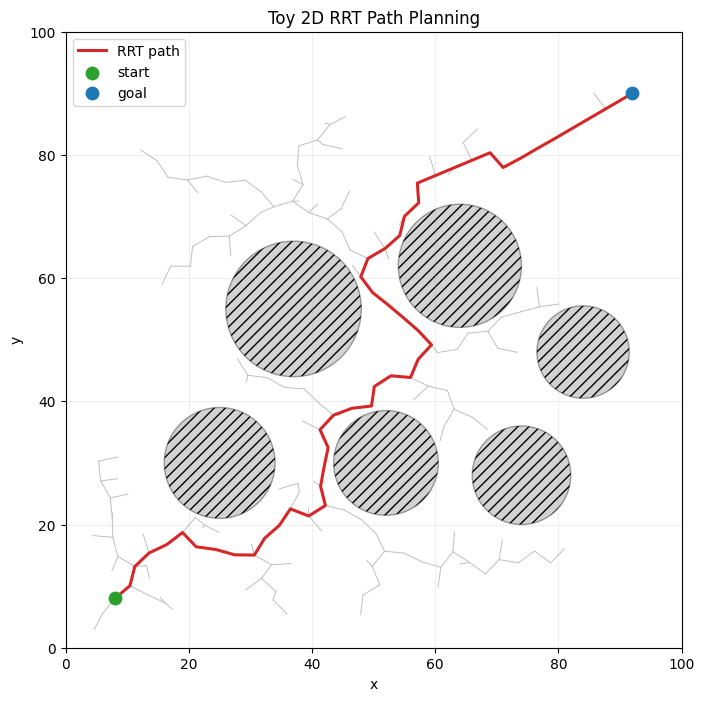

In [3]:
agent = Agent(
    field,
    start=start,
    rrt_params=RRTParameters(
        step_size=3.2,
        max_iters=4500,
        goal_bias=0.1,
        goal_tolerance=3.8,
        use_rrt_star=False,
        rrt_star_radius=10.0,
        seed=7,
    ),
)
path = agent.plan_to(goal)

if path is None:
    print("No path found. Try increasing max_iters or adjusting obstacles.")
else:
    print(f"Path found with {len(path)} waypoints")
    print(f"Path length: {agent.planner.path_length(path):.2f}")

plot_agent(agent, show=True, planner_name="RRT")

Path found with 20 waypoints
Path length: 130.94


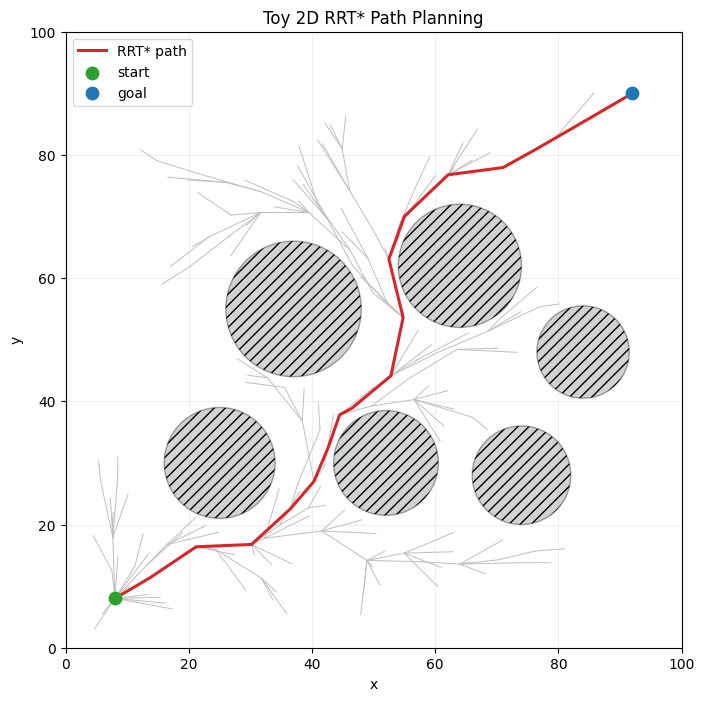

In [4]:
agent = Agent(
    field,
    start=start,
    rrt_params=RRTParameters(
        step_size=3.2,
        max_iters=4500,
        goal_bias=0.1,
        goal_tolerance=3.8,
        use_rrt_star=True,
        rrt_star_radius=10.0,
        seed=7,
    ),
)
path = agent.plan_to(goal)

if path is None:
    print("No path found. Try increasing max_iters or adjusting obstacles.")
else:
    print(f"Path found with {len(path)} waypoints")
    print(f"Path length: {agent.planner.path_length(path):.2f}")

plot_agent(agent, show=True, planner_name="RRT*")

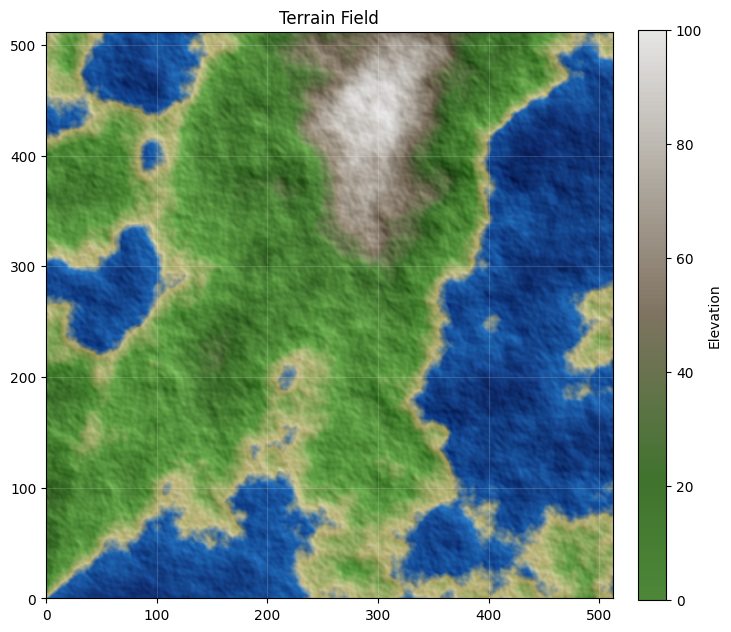

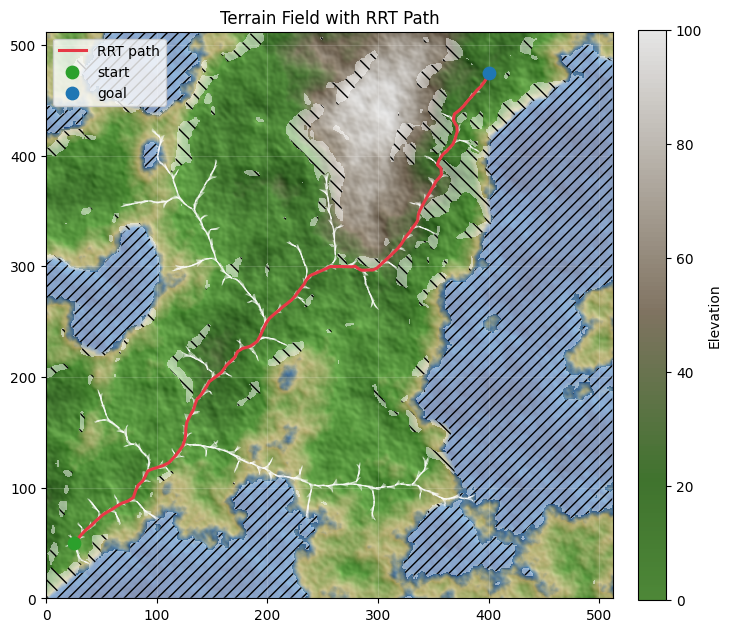

In [ ]:
from Agent import Agent
from FieldClass import TerrainFieldClass
from RRT import RRTParameters
from utils.visualization import plot_agent

terrain_field = TerrainFieldClass(seed=42)
terrain_field.plot(title="Terrain Field")

terrain_agent = Agent(
    terrain_field,
    start=(25.0, 50.0),
    rrt_params=RRTParameters(
        step_size=1.0,
        max_iters=5000,
        seed=7,
        use_rrt_star=True
    ),
    max_grade=30.0,
)
terrain_path = terrain_agent.move_to((400.0, 475.0))
plot_agent(terrain_agent, show=True, title="Terrain Field with RRT Path", planner_name="RRT")